# Statistical Power Analysis for A/B Experiments

**Power** = probability of detecting a real effect when it exists.

$$\text{Power} = 1 - \beta \quad (\beta = \text{Type II error rate})$$

This notebook covers three modes:

1. **Prospective** — before the experiment: how many users needed?
2. **Retrospective** — after the experiment: did we have enough power?
3. **Sensitivity** — what effect sizes are detectable at our sample size?

Plus a full audit of all 10 experiments.

**Sections:**
1. Sample Size Calculator
2. Prospective Power for exp_001
3. Retrospective Power for exp_001
4. Sensitivity Analysis
5. Power Curves
6. Runtime Calculator
7. Full Catalog Audit (All 10)
8. Design Recommendations

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

ROOT = Path.cwd() if "notebooks" not in str(Path.cwd()) else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ecommerce_analytics.analysis import (
    ExperimentCatalog,
    audit_all_experiments,
    load_experiment_data,
    power_curve,
    retrospective_power,
    sample_size_calculator,
    sample_size_curve,
    sensitivity_analysis,
)
from ecommerce_analytics.analysis.stats_framework import cohens_h, _BASELINE_RATES

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
pd.set_option("display.float_format", "{:.4f}".format)

ALPHA = 0.05
TARGET_POWER = 0.80
catalog = ExperimentCatalog()

---
## 1. Sample Size Calculator

**Question:** How many users do we need per variant to detect a given
lift at 80 % power?

In [2]:
# Example: exp_001 — Free Shipping Threshold
result = sample_size_calculator(
    baseline_rate=0.12,      # 12 % control conversion
    mde_relative=0.10,       # 10 % relative lift
    alpha=ALPHA,
    power=TARGET_POWER,
    daily_traffic=500,       # 500 orders/day
)

print("=" * 58)
print("  SAMPLE SIZE CALCULATOR — exp_001")
print("=" * 58)
for k, v in result.items():
    print(f"  {k:25s}: {v}")
print("=" * 58)

  SAMPLE SIZE CALCULATOR — exp_001
  baseline_rate            : 0.12
  mde_relative             : 0.1
  target_rate              : 0.132
  effect_size_h            : 0.0362
  alpha                    : 0.05
  power                    : 0.8
  n_per_variant            : 11999
  n_total                  : 23998
  runtime_days             : 48.0


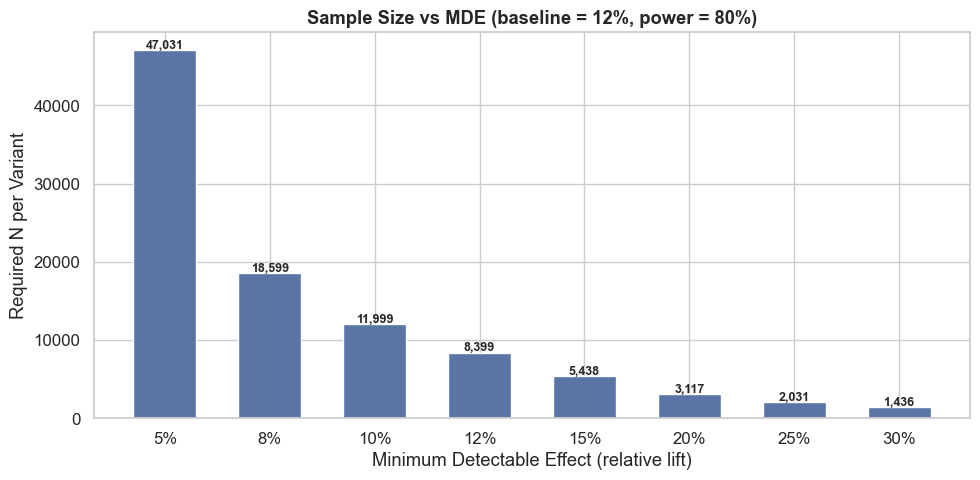

Key insight: halving the MDE roughly quadruples the required sample.
  MDE 20% -> n = 3,117
  MDE 10% -> n = 11,999
  MDE  5% -> n = 47,031


In [3]:
# How required N changes with different MDEs
mdes = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30]
baseline = 0.12
n_needed = [sample_size_calculator(baseline, mde)["n_per_variant"] for mde in mdes]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([f"{m:.0%}" for m in mdes], n_needed,
              color="#5975a4", edgecolor="white", width=0.6)
for bar, n in zip(bars, n_needed):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{n:,}", ha="center", fontweight="bold", fontsize=9)
ax.set_xlabel("Minimum Detectable Effect (relative lift)")
ax.set_ylabel("Required N per Variant")
ax.set_title("Sample Size vs MDE (baseline = 12%, power = 80%)", fontweight="bold")
plt.tight_layout()
plt.show()

print("Key insight: halving the MDE roughly quadruples the required sample.")
print(f"  MDE 20% -> n = {sample_size_calculator(baseline, 0.20)['n_per_variant']:,}")
print(f"  MDE 10% -> n = {sample_size_calculator(baseline, 0.10)['n_per_variant']:,}")
print(f"  MDE  5% -> n = {sample_size_calculator(baseline, 0.05)['n_per_variant']:,}")

---
## 2. Prospective Power — exp_001

Given the *planned* sample size from the experiment catalog, what
power would we achieve at the planned MDE?

In [4]:
meta = catalog.get("exp_001")
baseline_001 = _BASELINE_RATES["exp_001"]
target_001 = baseline_001 * (1 + meta.mde_percent / 100)
h_mde = abs(cohens_h(baseline_001, target_001))

from statsmodels.stats.power import NormalIndPower
engine = NormalIndPower()

planned_power = engine.solve_power(
    effect_size=h_mde, nobs1=meta.sample_per_variant,
    alpha=ALPHA, ratio=1.0, alternative="two-sided",
)

print(f"Experiment  : {meta.name}")
print(f"Baseline CR : {baseline_001:.2%}")
print(f"MDE         : {meta.mde_percent}% relative -> target {target_001:.2%}")
print(f"Effect size : Cohen's h = {h_mde:.4f}")
print(f"Planned n   : {meta.sample_per_variant:,} per variant")
print(f"Prospective power at planned n: {planned_power:.2%}")
print(f"Adequate?   : {'YES' if planned_power >= 0.80 else 'NO — need more sample'}")

Experiment  : Free Shipping Threshold
Baseline CR : 12.00%
MDE         : 10% relative -> target 13.20%
Effect size : Cohen's h = 0.0362
Planned n   : 2,450 per variant
Prospective power at planned n: 24.45%
Adequate?   : NO — need more sample


---
## 3. Retrospective Power — exp_001

With the *actual* sample size and *observed* effect, what power did we
actually achieve?

In [5]:
data = load_experiment_data("exp_001")
ctrl = data[data["variant"] == "control"]
treat = data[data["variant"] == "treatment"]

retro = retrospective_power(
    p_control=ctrl["converted"].mean(),
    p_treatment=treat["converted"].mean(),
    n_control=len(ctrl),
    n_treatment=len(treat),
    alpha=ALPHA,
)

print("=" * 58)
print("  RETROSPECTIVE POWER — exp_001")
print("=" * 58)
for k, v in retro.items():
    if isinstance(v, float):
        print(f"  {k:25s}: {v:.4f}")
    else:
        print(f"  {k:25s}: {v}")
print("=" * 58)

if retro["adequate"]:
    print("\nConclusion: The experiment was well-powered. We can trust")
    print("both significant and non-significant results.")
else:
    print("\nConclusion: UNDERPOWERED. Non-significant results could be")
    print("due to insufficient sample, not absence of effect.")

  RETROSPECTIVE POWER — exp_001
  p_control                : 0.1201
  p_treatment              : 0.1345
  observed_lift            : 11.9500
  effect_size_h            : 0.0431
  n_control                : 49782
  n_treatment              : 49659
  achieved_power           : 1.0000
  adequate                 : True
  alpha                    : 0.0500

Conclusion: The experiment was well-powered. We can trust
both significant and non-significant results.


---
## 4. Sensitivity Analysis

**Question:** Given our actual sample size, what is the *smallest effect*
we could reliably detect?

In [6]:
actual_n = min(len(ctrl), len(treat))
sens = sensitivity_analysis(actual_n, alpha=ALPHA)

# Convert Cohen's h back to approximate relative lifts
import math
sens["approx_lift_%"] = sens["min_detectable_effect"].apply(
    lambda h: round(
        ((math.sin(math.asin(math.sqrt(baseline_001)) + h / 2)) ** 2
         - baseline_001) / baseline_001 * 100, 1
    ) if not np.isnan(h) else np.nan
)

print(f"With n = {actual_n:,} per variant (exp_001):")
print()
print(sens.to_string(index=False))
print()
row_80 = sens[sens["power"] == 0.80].iloc[0]
print(f"At 80% power we can detect lifts >= {row_80['approx_lift_%']:.1f}% relative.")
print(f"Our MDE target was {meta.mde_percent}% — {'achievable' if row_80['approx_lift_%'] <= meta.mde_percent else 'NOT achievable'}.")

With n = 49,659 per variant (exp_001):

 power  min_detectable_effect  approx_lift_%
0.5000                 0.0124         3.4000
0.6000                 0.0140         3.8000
0.7000                 0.0158         4.3000
0.8000                 0.0178         4.9000
0.9000                 0.0206         5.6000
0.9500                 0.0229         6.3000

At 80% power we can detect lifts >= 4.9% relative.
Our MDE target was 10% — achievable.


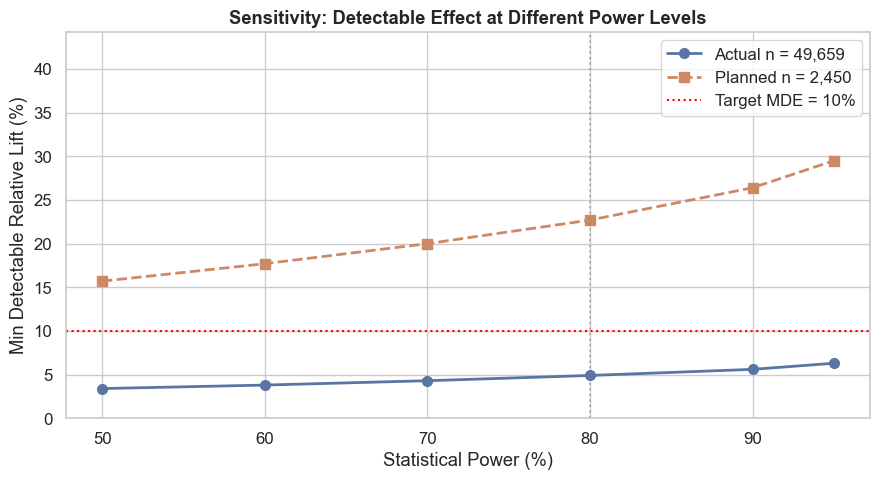

In [7]:
# Sensitivity at planned n vs actual n
sens_planned = sensitivity_analysis(meta.sample_per_variant, alpha=ALPHA)
sens_planned["approx_lift_%"] = sens_planned["min_detectable_effect"].apply(
    lambda h: round(
        ((math.sin(math.asin(math.sqrt(baseline_001)) + h / 2)) ** 2
         - baseline_001) / baseline_001 * 100, 1
    ) if not np.isnan(h) else np.nan
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sens["power"] * 100, sens["approx_lift_%"], "o-",
        color="#5975a4", linewidth=2, markersize=7,
        label=f"Actual n = {actual_n:,}")
ax.plot(sens_planned["power"] * 100, sens_planned["approx_lift_%"], "s--",
        color="#cc8963", linewidth=2, markersize=7,
        label=f"Planned n = {meta.sample_per_variant:,}")
ax.axhline(meta.mde_percent, color="red", linestyle=":",
           label=f"Target MDE = {meta.mde_percent}%")
ax.axvline(80, color="grey", linestyle=":", alpha=0.5)
ax.set_xlabel("Statistical Power (%)")
ax.set_ylabel("Min Detectable Relative Lift (%)")
ax.set_title("Sensitivity: Detectable Effect at Different Power Levels", fontweight="bold")
ax.legend()
ax.set_ylim(0, max(sens_planned["approx_lift_%"].max(), meta.mde_percent) * 1.5)
plt.tight_layout()
plt.show()

---
## 5. Power Curves

Two complementary views: (a) power vs effect size at fixed n,
and (b) power vs sample size at fixed effect.

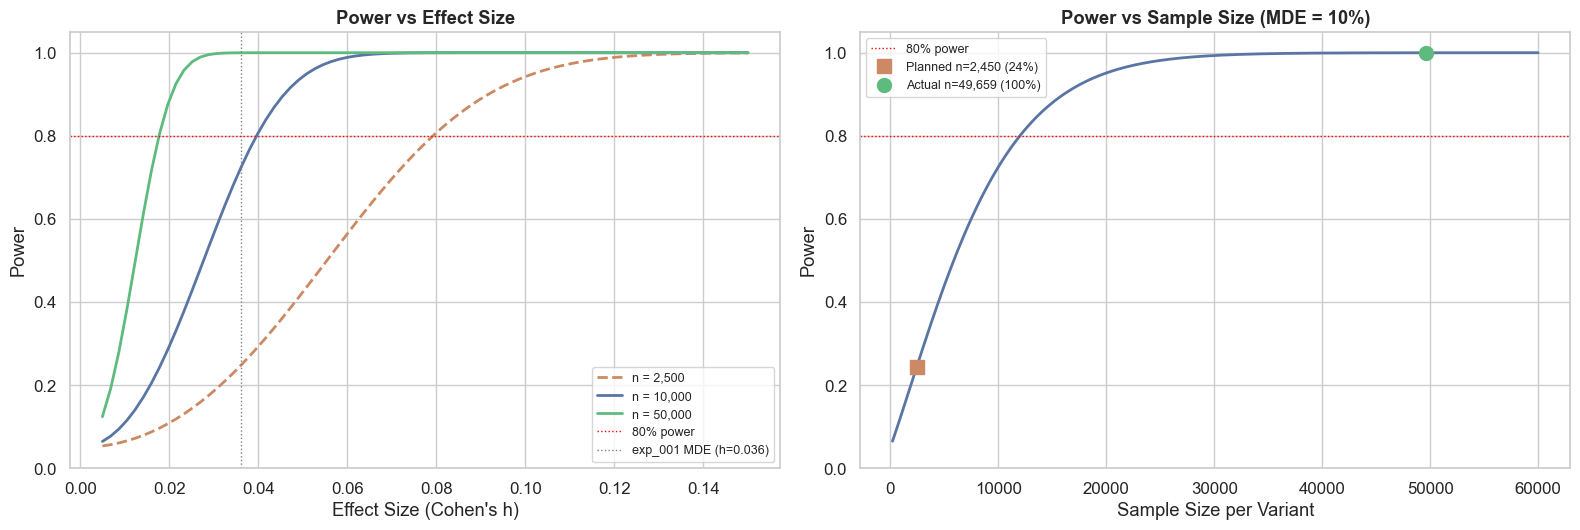

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# ── 5a  Power vs effect size ───────────────────────────────────────
ax = axes[0]
for n_val, color, ls in [(2_500, "#cc8963", "--"),
                          (10_000, "#5975a4", "-"),
                          (50_000, "#5fba7d", "-")]:
    pc = power_curve(n_per_variant=n_val, alpha=ALPHA)
    ax.plot(pc["effect_size"], pc["power"], color=color, linestyle=ls,
            linewidth=2, label=f"n = {n_val:,}")

ax.axhline(0.80, color="red", linestyle=":", linewidth=1, label="80% power")
ax.axvline(h_mde, color="grey", linestyle=":", linewidth=1,
           label=f"exp_001 MDE (h={h_mde:.3f})")
ax.set_xlabel("Effect Size (Cohen's h)")
ax.set_ylabel("Power")
ax.set_title("Power vs Effect Size", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

# ── 5b  Power vs sample size ──────────────────────────────────────
ax = axes[1]
sc = sample_size_curve(h_mde, alpha=ALPHA)
ax.plot(sc["n_per_variant"], sc["power"], linewidth=2, color="#5975a4")
ax.axhline(0.80, color="red", linestyle=":", linewidth=1, label="80% power")

# Mark planned and actual
plan_pwr = engine.solve_power(effect_size=h_mde, nobs1=meta.sample_per_variant,
                               alpha=ALPHA, ratio=1.0, alternative="two-sided")
act_pwr = engine.solve_power(effect_size=h_mde, nobs1=actual_n,
                              alpha=ALPHA, ratio=1.0, alternative="two-sided")
ax.plot(meta.sample_per_variant, plan_pwr, "s", color="#cc8963", markersize=10,
        label=f"Planned n={meta.sample_per_variant:,} ({plan_pwr:.0%})")
ax.plot(actual_n, act_pwr, "o", color="#5fba7d", markersize=10,
        label=f"Actual n={actual_n:,} ({act_pwr:.0%})")

ax.set_xlabel("Sample Size per Variant")
ax.set_ylabel("Power")
ax.set_title(f"Power vs Sample Size (MDE = {meta.mde_percent}%)", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

---
## 6. Runtime Calculator

How long must the experiment run to collect enough data?

In [9]:
traffic_levels = [100, 250, 500, 1000, 2000, 5000]
runtime_rows = []

for exp_id in catalog.list_ids():
    m = catalog.get(exp_id)
    bl = _BASELINE_RATES.get(exp_id, 0.12)
    ss = sample_size_calculator(bl, m.mde_percent / 100, alpha=ALPHA, power=TARGET_POWER)
    for traffic in traffic_levels:
        days = ss["n_total"] / traffic
        runtime_rows.append({
            "experiment": m.name[:25],
            "n_total": ss["n_total"],
            "traffic/day": traffic,
            "days": round(days, 1),
            "weeks": round(days / 7, 1),
        })

runtime_df = pd.DataFrame(runtime_rows)

# Show for 500 orders/day
r500 = runtime_df[runtime_df["traffic/day"] == 500][
    ["experiment", "n_total", "days", "weeks"]
].reset_index(drop=True)
print("Runtime at 500 orders/day:")
print(r500.to_string(index=False))

Runtime at 500 orders/day:
               experiment  n_total     days   weeks
  Free Shipping Threshold    23998  48.0000  6.9000
Payment Installments (6 v    17118  34.2000  4.9000
        One-Page Checkout    28698  57.4000  8.2000
Review Solicitation Timin     2970   5.9000  0.8000
Product Recommendations (    20646  41.3000  5.9000
Delivery Speed Options (S    78740 157.5000 22.5000
Seller Ratings Display (S    26494  53.0000  7.6000
Bundle Discounts (3 items     4384   8.8000  1.3000
Guest Checkout (Guest vs     15038  30.1000  4.3000
Dynamic Pricing (Demand-B    85812 171.6000 24.5000


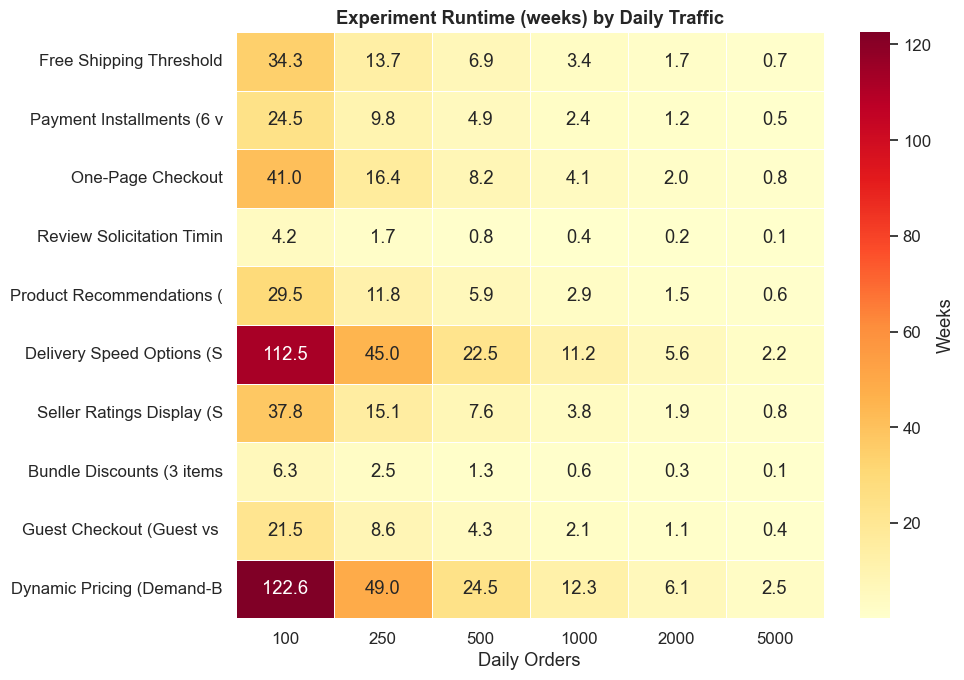

In [10]:
# Heatmap: runtime (weeks) by experiment x traffic level
pivot = runtime_df.pivot_table(index="experiment", columns="traffic/day",
                                values="weeks", aggfunc="first")
pivot = pivot.loc[r500["experiment"].values]  # preserve order

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Weeks"})
ax.set_title("Experiment Runtime (weeks) by Daily Traffic", fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("Daily Orders")
plt.tight_layout()
plt.show()

---
## 7. Full Catalog Audit — All 10 Experiments

Compare planned vs required vs actual sample sizes and flag
under/over-powered experiments.

In [11]:
audit = audit_all_experiments(alpha=ALPHA, target_power=TARGET_POWER)

display_cols = [
    "experiment_name", "baseline_rate", "mde_%",
    "planned_n", "required_n_80%", "actual_n_ctrl",
    "prospective_power", "achieved_power", "adequate",
]
audit[display_cols]

,experiment_name,baseline_rate,mde_%,planned_n,required_n_80%,actual_n_ctrl,prospective_power,achieved_power,adequate
0,Free Shipping Threshold,0.1200,10,2450,11999,49782,0.2445,1.0000,True
1,Payment Installments (6 vs 12 months),0.0800,15,3200,8559,49741,0.4026,1.0000,True
2,One-Page Checkout,0.1500,8,3500,14349,49700,0.2826,0.9726,True
3,Review Solicitation Timing (3d vs 7d),0.2200,20,1800,1485,49349,0.8697,1.0000,True
4,Product Recommendations (Personalized vs Popular),0.1000,12,2700,10323,49732,0.2994,1.0000,True
5,Delivery Speed Options (Standard vs Express),0.1400,5,6200,39370,49853,0.1992,0.9961,True
6,Seller Ratings Display (Show vs Hide),0.1100,10,2500,13247,49757,0.2295,0.9998,True
7,Bundle Discounts (3 items for 10% off),0.2500,15,350,2192,49767,0.2014,1.0000,True
8,Guest Checkout (Guest vs Forced Registration),0.0900,15,1900,7519,49673,0.2910,1.0000,True
9,Dynamic Pricing (Demand-Based),0.1300,5,1200,42906,50088,0.0755,0.7184,False


In [12]:
# Summary
n_adequate = int(audit["adequate"].sum())
n_overpowered = int(audit["overpowered"].sum())
n_underpowered = len(audit) - n_adequate

print("=" * 58)
print("  POWER AUDIT SUMMARY")
print("=" * 58)
print(f"  Total experiments     : {len(audit)}")
print(f"  Adequately powered    : {n_adequate}")
print(f"  Overpowered (>99%)    : {n_overpowered}")
print(f"  Underpowered (<80%)   : {n_underpowered}")
print("=" * 58)

if n_underpowered > 0:
    print("\nUnderpowered experiments:")
    under = audit[~audit["adequate"]]
    for _, row in under.iterrows():
        shortfall = row["required_n_80%"] - row["actual_n_ctrl"]
        print(f"  {row['experiment_name']}: power={row['achieved_power']:.0%}, "
              f"need {shortfall:,} more per variant")

  POWER AUDIT SUMMARY
  Total experiments     : 10
  Adequately powered    : 9
  Overpowered (>99%)    : 8
  Underpowered (<80%)   : 1

Underpowered experiments:
  Dynamic Pricing (Demand-Based): power=72%, need -7,182 more per variant


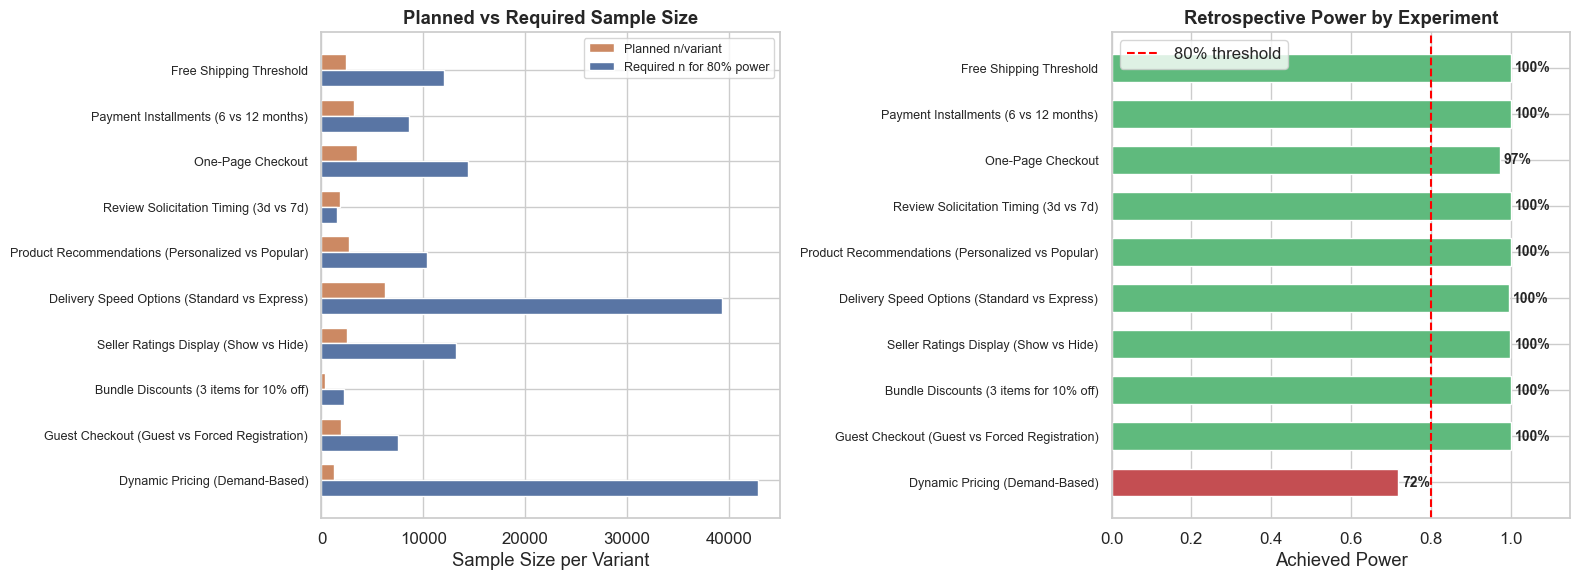

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── 7a  Planned vs Required sample sizes ──────────────────────────
ax = axes[0]
y = np.arange(len(audit))
w = 0.35
ax.barh(y - w/2, audit["planned_n"], w, color="#cc8963",
        label="Planned n/variant", edgecolor="white")
ax.barh(y + w/2, audit["required_n_80%"], w, color="#5975a4",
        label="Required n for 80% power", edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(audit["experiment_name"], fontsize=9)
ax.set_xlabel("Sample Size per Variant")
ax.set_title("Planned vs Required Sample Size", fontweight="bold")
ax.legend(fontsize=9)
ax.invert_yaxis()

# ── 7b  Achieved power bar chart ──────────────────────────────────
ax = axes[1]
colors = ["#5fba7d" if p >= 0.80 else "#c44e52" for p in audit["achieved_power"]]
bars = ax.barh(y, audit["achieved_power"], color=colors,
               height=0.6, edgecolor="white")
ax.axvline(0.80, color="red", linestyle="--", linewidth=1.5,
           label="80% threshold")
for i, (bar, pwr) in enumerate(zip(bars, audit["achieved_power"])):
    ax.text(bar.get_width() + 0.01, i,
            f"{pwr:.0%}", va="center", fontweight="bold", fontsize=10)
ax.set_yticks(y)
ax.set_yticklabels(audit["experiment_name"], fontsize=9)
ax.set_xlabel("Achieved Power")
ax.set_title("Retrospective Power by Experiment", fontweight="bold")
ax.legend()
ax.set_xlim(0, 1.15)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

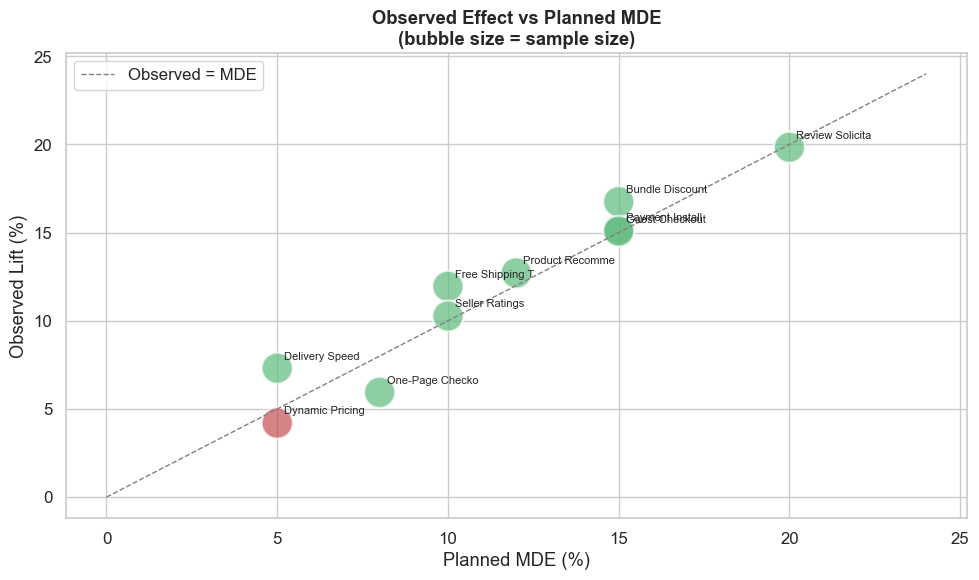

In [14]:
# Observed lift vs required lift for detection
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(audit["mde_%"], audit["observed_lift_%"],
           s=audit["actual_n_ctrl"] / 100, alpha=0.7,
           c=["#5fba7d" if a else "#c44e52" for a in audit["adequate"]],
           edgecolors="white", linewidth=1.5)

# Add experiment labels
for _, row in audit.iterrows():
    ax.annotate(row["experiment_name"][:15],
                (row["mde_%"], row["observed_lift_%"]),
                fontsize=8, ha="left", va="bottom",
                xytext=(5, 5), textcoords="offset points")

# Diagonal: observed = planned MDE
lims = [0, max(audit["mde_%"].max(), audit["observed_lift_%"].max()) * 1.2]
ax.plot(lims, lims, "--", color="grey", linewidth=1, label="Observed = MDE")
ax.set_xlabel("Planned MDE (%)")
ax.set_ylabel("Observed Lift (%)")
ax.set_title("Observed Effect vs Planned MDE\n(bubble size = sample size)",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Design Recommendations

Based on the power audit, here are actionable recommendations for
experiment design.

In [15]:
print("=" * 65)
print("  EXPERIMENT DESIGN RECOMMENDATIONS")
print("=" * 65)
print()

for _, row in audit.iterrows():
    status = "OK" if row["adequate"] else "UNDERPOWERED"
    emoji = "[OK]" if row["adequate"] else "[!!]"
    print(f"{emoji} {row['experiment_name']}")
    print(f"    Planned n: {row['planned_n']:,}  |  Required: {row['required_n_80%']:,}  |  "
          f"Actual: {row['actual_n_ctrl']:,}")
    print(f"    Prospective power: {row['prospective_power']:.0%}  |  "
          f"Achieved: {row['achieved_power']:.0%}")
    if row["overpowered"]:
        print(f"    Note: Overpowered (>99%). Could have stopped earlier.")
    elif not row["adequate"]:
        gap = row["required_n_80%"] - row["actual_n_ctrl"]
        print(f"    Action: Need {gap:,} more users/variant, or relax MDE.")
    print()

  EXPERIMENT DESIGN RECOMMENDATIONS

[OK] Free Shipping Threshold
    Planned n: 2,450  |  Required: 11,999  |  Actual: 49,782
    Prospective power: 24%  |  Achieved: 100%
    Note: Overpowered (>99%). Could have stopped earlier.

[OK] Payment Installments (6 vs 12 months)
    Planned n: 3,200  |  Required: 8,559  |  Actual: 49,741
    Prospective power: 40%  |  Achieved: 100%
    Note: Overpowered (>99%). Could have stopped earlier.

[OK] One-Page Checkout
    Planned n: 3,500  |  Required: 14,349  |  Actual: 49,700
    Prospective power: 28%  |  Achieved: 97%

[OK] Review Solicitation Timing (3d vs 7d)
    Planned n: 1,800  |  Required: 1,485  |  Actual: 49,349
    Prospective power: 87%  |  Achieved: 100%
    Note: Overpowered (>99%). Could have stopped earlier.

[OK] Product Recommendations (Personalized vs Popular)
    Planned n: 2,700  |  Required: 10,323  |  Actual: 49,732
    Prospective power: 30%  |  Achieved: 100%
    Note: Overpowered (>99%). Could have stopped earlier.

[

In [16]:
# Final summary table
final = audit[[
    "experiment_name", "baseline_rate", "mde_%",
    "planned_n", "required_n_80%", "actual_n_ctrl",
    "observed_lift_%", "achieved_power", "adequate",
]].copy()
final.columns = [
    "Experiment", "Baseline", "MDE %",
    "Planned N", "Required N", "Actual N",
    "Obs. Lift %", "Power", "Adequate",
]
final.style.hide(axis="index").applymap(
    lambda v: "background-color: #d4edda" if v is True
              else "background-color: #f8d7da" if v is False else "",
    subset=["Adequate"]
).format({
    "Baseline": "{:.2%}",
    "Power": "{:.0%}",
    "Planned N": "{:,}",
    "Required N": "{:,}",
    "Actual N": "{:,}",
})

Experiment,Baseline,MDE %,Planned N,Required N,Actual N,Obs. Lift %,Power,Adequate
Free Shipping Threshold,12.00%,10,"2,450","11,999","49,782",11.950000,100%,True
Payment Installments (6 vs 12 months),8.00%,15,"3,200","8,559","49,741",15.160000,100%,True
One-Page Checkout,15.00%,8,"3,500","14,349","49,700",5.940000,97%,True
Review Solicitation Timing (3d vs 7d),22.00%,20,"1,800","1,485","49,349",19.840000,100%,True
Product Recommendations (Personalized vs Popular),10.00%,12,"2,700","10,323","49,732",12.710000,100%,True
Delivery Speed Options (Standard vs Express),14.00%,5,"6,200","39,370","49,853",7.310000,100%,True
Seller Ratings Display (Show vs Hide),11.00%,10,"2,500","13,247","49,757",10.270000,100%,True
Bundle Discounts (3 items for 10% off),25.00%,15,350,"2,192","49,767",16.750000,100%,True
Guest Checkout (Guest vs Forced Registration),9.00%,15,"1,900","7,519","49,673",15.080000,100%,True
Dynamic Pricing (Demand-Based),13.00%,5,"1,200","42,906","50,088",4.200000,72%,False


---
## Key Takeaways

| Concept | Rule of Thumb |
|---|---|
| Target power | >= 80% (industry standard) |
| Smaller MDE | Requires quadratically more sample |
| Lower baseline rate | Needs larger sample (harder to detect lift on rare events) |
| Overpowered (>99%) | Could use smaller sample or detect smaller effects |
| Underpowered (<80%) | Non-significant results are inconclusive, not proof of no effect |
| Runtime | n_total / daily_traffic — plan for weeks, not days |

### When Power Analysis Matters Most

| Scenario | Why |
|---|---|
| Before launch | Ensure experiment can detect the MDE with available traffic |
| Non-significant result | Was it underpowered, or truly no effect? |
| Budget constrained | Find the largest MDE detectable within budget |
| Stakeholder pushback | Justify test duration with power calculation |